<a href="https://colab.research.google.com/github/Soumit2k05/MP-1-7th-Sem-Soumit-Subhasish-Roshan-Rajaram/blob/main/03a_xgboost_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Install libraries not available by default on Colab
!pip install xgboost optuna shap --quiet

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna
import shap
import joblib
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('All libraries loaded successfully')
print(f'XGBoost version: {xgb.__version__}')

All libraries loaded successfully
XGBoost version: 3.3.0


In [6]:
from google.colab import drive
drive.mount('/content/drive')

# ✏️ UPDATE THIS PATH to match your shared Drive folder
DATA_PATH = '/content/PJME_hourly.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['Datetime'], index_col='Datetime')
df = df.sort_index()
print(f'Dataset shape: {df.shape}')
print(f'Date range:    {df.index.min()}  to  {df.index.max()}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (145366, 1)
Date range:    2002-01-01 01:00:00  to  2018-08-03 00:00:00
Columns: ['PJME_MW']


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0


Sanity Check: No Nulls, Correct Types

In [7]:
print('=== NULL CHECK ===')
print(df.isnull().sum())
print()
print('=== DATA TYPES ===')
print(df.dtypes)
print()
print(f'Target (PJME_MW) — min: {df.PJME_MW.min():.0f} MW,  max: {df.PJME_MW.max():.0f} MW')

=== NULL CHECK ===
PJME_MW    0
dtype: int64

=== DATA TYPES ===
PJME_MW    float64
dtype: object

Target (PJME_MW) — min: 14544 MW,  max: 62009 MW


Define Features & Target, Chronological Train/Test Split
> We split by date, NOT randomly. Train on 2002–2015, test on 2015–2018. This prevents data leakage.

In [8]:
FEATURES = ['Hour', 'Day', 'Month', 'Weekday', 'Weekend',
            'Quarter', 'Year', 'Lag_1', 'Lag_24', 'Lag_168',
            'Rolling_Mean_24', 'Rolling_Mean_168']
TARGET = 'PJME_MW'

# Create time-based features
df['Hour'] = df.index.hour
df['Day'] = df.index.day
df['Month'] = df.index.month
df['Weekday'] = df.index.weekday
df['Weekend'] = (df.index.dayofweek >= 5).astype(int) # 0 for weekday, 1 for weekend
df['Quarter'] = df.index.quarter
df['Year'] = df.index.year

# Create lag features
df['Lag_1'] = df[TARGET].shift(1)
df['Lag_24'] = df[TARGET].shift(24)
df['Lag_168'] = df[TARGET].shift(168) # 7 days * 24 hours

# Create rolling mean features
df['Rolling_Mean_24'] = df[TARGET].rolling(window=24).mean()
df['Rolling_Mean_168'] = df[TARGET].rolling(window=168).mean()

# Drop rows with NaN values introduced by lagging and rolling mean
# The earliest rows will have NaNs for lag and rolling features
df.dropna(inplace=True)

SPLIT_DATE = '2015-01-01'

train = df[df.index < SPLIT_DATE]
test  = df[df.index >= SPLIT_DATE]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f'Training rows: {len(X_train):,}  ({X_train.index.min().date()} to {X_train.index.max().date()})')
print(f'Testing rows:  {len(X_test):,}   ({X_test.index.min().date()} to {X_test.index.max().date()})')

Training rows: 113,758  (2002-01-08 to 2014-12-31)
Testing rows:  31,440   (2015-01-01 to 2018-08-03)


XGBoost Baseline (Default Parameters)


In [9]:
xgb_baseline = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_baseline.fit(X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False)

y_pred_base = xgb_baseline.predict(X_test)

mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base   = r2_score(y_test, y_pred_base)

print('=== XGBoost Baseline Results ===')
print(f'MAE :  {mae_base:.2f} MW')
print(f'RMSE:  {rmse_base:.2f} MW')
print(f'R²  :  {r2_base:.4f}')

=== XGBoost Baseline Results ===
MAE :  354.77 MW
RMSE:  469.87 MW
R²  :  0.9947


Define Optuna Objective Function
> Optuna uses Tree-structured Parzen Estimator (TPE) — it learns which parameter regions to explore next, unlike grid search which tries everything blindly.

In [10]:
def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'       : trial.suggest_int('max_depth', 4, 12),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma'           : trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.5, 2.0),
        'random_state'    : 42,
        'n_jobs'          : -1,
        'verbosity'       : 0
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    preds = model.predict(X_test)
    return mean_squared_error(y_test, preds)  # Optuna minimises this

print('Objective function defined.')

Objective function defined.


Run Optuna Study


In [11]:
study = optuna.create_study(direction='minimize',
                            study_name='xgboost_pjm_load')

study.optimize(objective, n_trials=60, show_progress_bar=True)

print('=== Best Trial ===')
print(f'  MSE (objective): {study.best_value:.2f}')
print('  Best parameters:')
for k, v in study.best_params.items():
    print(f'    {k}: {v}')

  0%|          | 0/60 [00:00<?, ?it/s]

=== Best Trial ===
  MSE (objective): 137551.47
  Best parameters:
    n_estimators: 720
    max_depth: 8
    learning_rate: 0.05430263984559455
    subsample: 0.985049673889957
    colsample_bytree: 0.9760465031777628
    min_child_weight: 7
    gamma: 0.07310412461479925
    reg_alpha: 0.4265722851225855
    reg_lambda: 0.6828524502738211


Train Final XGBoost on Best Parameters

In [13]:
xgb_tuned = xgb.XGBRegressor(**study.best_params, random_state=42, n_jobs=-1, verbosity=0)
xgb_tuned.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_tuned = xgb_tuned.predict(X_test)

mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned   = r2_score(y_test, y_pred_tuned)

print('=== Tuned XGBoost Results ===')
print(f'MAE :  {mae_tuned:.2f} MW')
print(f'RMSE:  {rmse_tuned:.2f} MW')
print(f'R²  :  {r2_tuned:.4f}')
print()
print(f'MAE  improvement over baseline: {mae_base - mae_tuned:.2f} MW')
print(f'RMSE improvement over baseline: {rmse_base - rmse_tuned:.2f} MW')

=== Tuned XGBoost Results ===
MAE :  269.41 MW
RMSE:  370.88 MW
R²  :  0.9967

MAE  improvement over baseline: 85.36 MW
RMSE improvement over baseline: 98.99 MW


 Actual vs. Predicted Chart (Last 500 Hours)

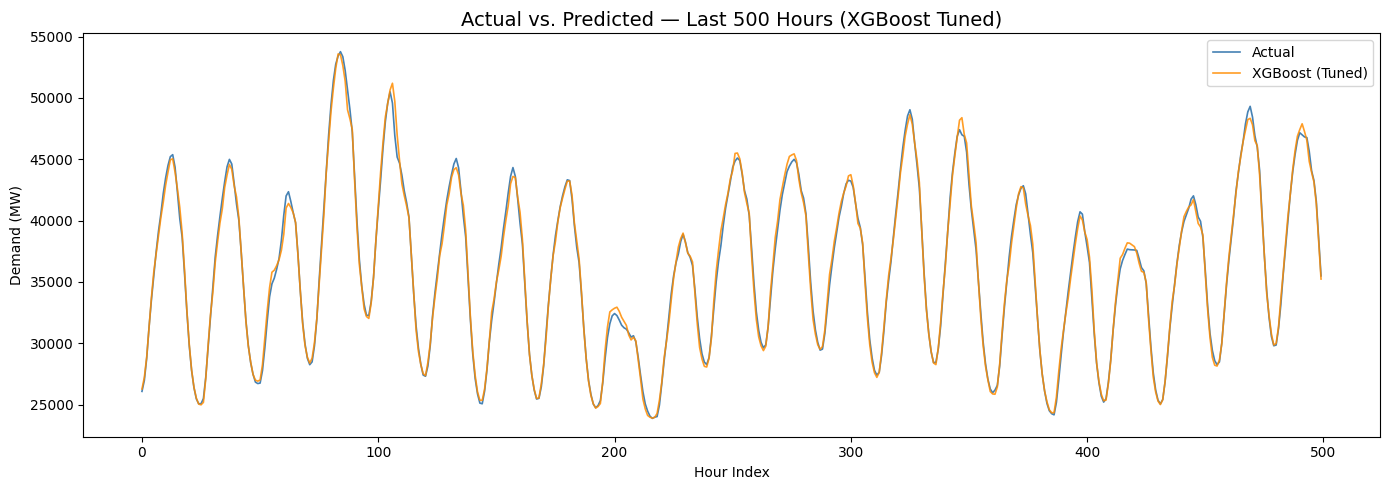

Saved: actual_vs_predicted_xgb.png


In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test.values[-500:], label='Actual',          color='steelblue', linewidth=1.2)
ax.plot(y_pred_tuned[-500:],  label='XGBoost (Tuned)', color='darkorange', linewidth=1.2, alpha=0.85)
ax.set_title('Actual vs. Predicted — Last 500 Hours (XGBoost Tuned)', fontsize=14)
ax.set_xlabel('Hour Index')
ax.set_ylabel('Demand (MW)')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: actual_vs_predicted_xgb.png')

Optuna Optimisation History Plot

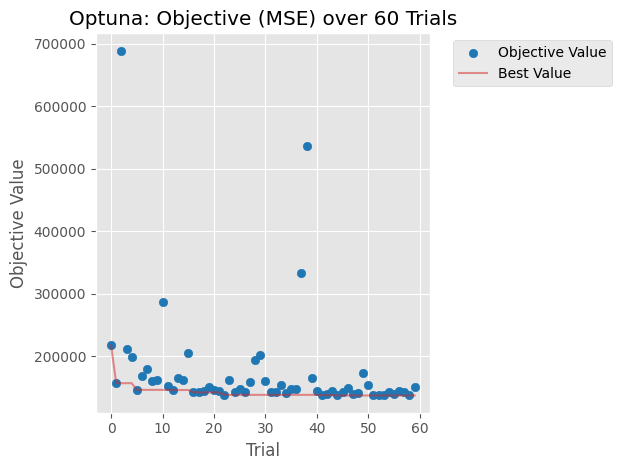

In [15]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optuna: Objective (MSE) over 60 Trials')
plt.tight_layout()
plt.savefig('optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

Compute SHAP Values (TreeExplainer)


In [16]:
explainer   = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values shape: {shap_values.shape}')  # should be (test_rows, 12)
print('SHAP computation complete.')

SHAP values shape: (31440, 12)
SHAP computation complete.


SHAP Summary Plot (Beeswarm)
> Most important SHAP chart. Each dot = one test sample. X-axis = feature's push on prediction. Colour = feature value (red=high, blue=low).

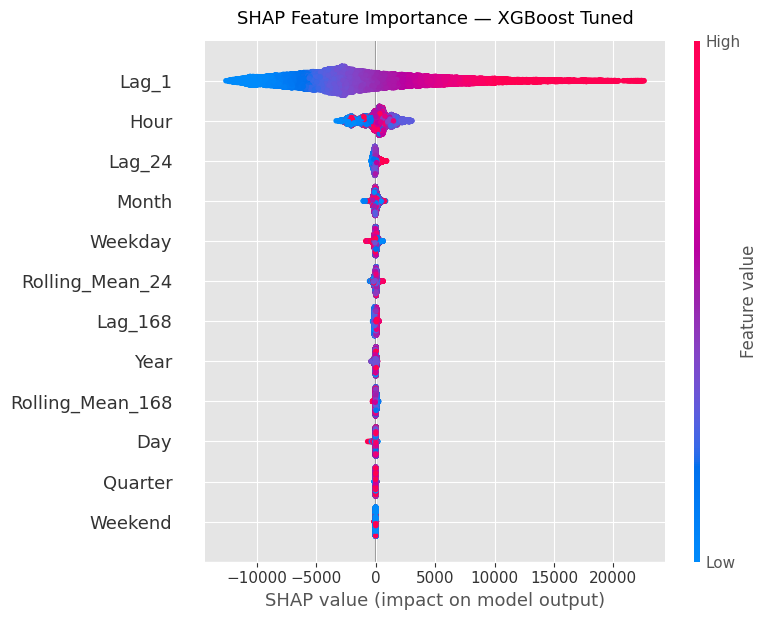

Saved: shap_summary.png


In [17]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Feature Importance — XGBoost Tuned', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_summary.png')

SHAP Dependence Plot (Lag_24 vs Hour)

<Figure size 900x500 with 0 Axes>

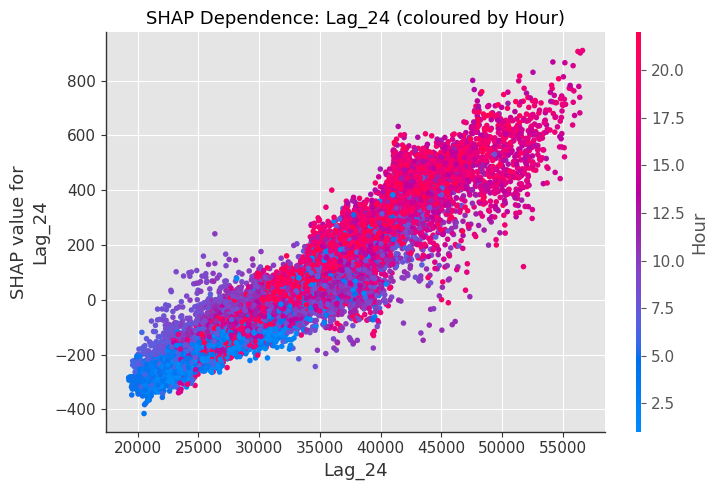

In [18]:
plt.figure(figsize=(9, 5))
shap.dependence_plot('Lag_24', shap_values, X_test,
                     interaction_index='Hour',
                     feature_names=FEATURES, show=False)
plt.title('SHAP Dependence: Lag_24 (coloured by Hour)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_dependence_lag24.png', dpi=150, bbox_inches='tight')
plt.show()

Save Tuned Model to Drive

In [20]:
import os

MODEL_SAVE_PATH = '/content/drive/MyDrive/LoadForecasting/xgb_tuned_model.pkl'

# Ensure the directory exists
output_dir = os.path.dirname(MODEL_SAVE_PATH)
if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

joblib.dump(xgb_tuned, MODEL_SAVE_PATH)
print(f'Model saved to: {MODEL_SAVE_PATH}')

Model saved to: /content/drive/MyDrive/LoadForecasting/xgb_tuned_model.pkl


 Results Summary


In [21]:
print('=' * 50)
print('  DAY 1 RESULTS SUMMARY')
print('=' * 50)
print(f'  XGBoost Baseline  — MAE: {mae_base:.1f}  RMSE: {rmse_base:.1f}  R²: {r2_base:.4f}')
print(f'  XGBoost Tuned     — MAE: {mae_tuned:.1f}  RMSE: {rmse_tuned:.1f}  R²: {r2_tuned:.4f}')
print('=' * 50)
print('Files saved:')
print('  actual_vs_predicted_xgb.png')
print('  optuna_history.png')
print('  shap_summary.png')
print('  shap_dependence_lag24.png')
print('  xgb_tuned_model.pkl')

  DAY 1 RESULTS SUMMARY
  XGBoost Baseline  — MAE: 354.8  RMSE: 469.9  R²: 0.9947
  XGBoost Tuned     — MAE: 269.4  RMSE: 370.9  R²: 0.9967
Files saved:
  actual_vs_predicted_xgb.png
  optuna_history.png
  shap_summary.png
  shap_dependence_lag24.png
  xgb_tuned_model.pkl
